# Cross-Sectional Regression - Design Choices
When estimating a cross-sectional regression, the researcher has to make 3 design choices:

1. To include or not an intercept in the second stage regression
2. To include or not the factors as test assets
3. To use the OLS or GLS estimators

All three decisions come down to variations on the same theme: impose the null to gain efficiency, or leave it free to gain robustness. In this notebook, we'll explain the tradeoff and the guidelines, and visualize the effects of such choices.

### 1. Intercept in the second-stage regression
The model says the constant (the zero-beta excess return) should be zero. So the choice is whether to impose that restriction or estimate a free constant and check that it comes out small. The standard efficiency-vs-robustness trade-off applies: imposing no intercept is more efficient if the null holds. Estimating one is more robust if the true zero-beta rate differs from the risk-free rate, which is a common empirical finding. The estimated zero-beta rate often lands above the risk-free rate.

**Guideline**: if you trust the model down to the zero-beta rate, impose no intercept. If you want to guard against a nonzero zero-beta rate, estimate the constant and inspect it. For this second case, remember that on excess returns a free intercept doesn't discipline the risk-free-rate pricing error.

### 2. Including the factors as test assets
Economically, if the factors are returns, including the factors as test assets enforces the sensible restriction that the model must price its own factors. The OLS estimators adds these factor as new observations in the second stage, but the GLS estimator weighs them heavily forcing the factors to be perfectly priced.

When the factor is not a return you don't have this choice at all. You can't include it as a test asset, and the time-series test is unavailable, so you're forced into the cross-sectional regression.

If the factor is a return, and you run GLS, including the factors as test assets makes the cross-sectional regression identical to the time-series regression. The factor's own time-series regression is a perfect fit, so it has zero residual variance. GLS therefore loads entirely on it and returns the factor average as its risk premia, exactly like the time-series regression. The same collapse happens whenever the test assets span the factor.

**Guideline**: when factors are tradable returns, including them or not matters most under GLS. Under OLS the effect is milder. Exclude them only if you specifically want the cross-sectional fit across the other assets to speak on its own.

### 3. OLS vs GLS
Textbook advice is GLS, since the cross-sectional residuals are correlated. GLS is asymptotically more efficient and, if your goal is to reject a model, it focuses the test on the most statistically informative portfolios, which is what an efficient test should do.

**Guideline**: use GLS when number of assets $N$ is small relative to the time-series sample size $T$, you trust the estimate of the error covariance matrix of the first stage $\Sigma$, and you want statistical efficiency or maximum power to reject. Use OLS when $N$ is large relative to $T$, and when $\Sigma$ is poorly estimated, the model is understood to be an approximation, or you want robust, economically interpretable estimates.


# Visualization of the Design Choices
To get an intuition of the impact these choices have on the estimates, we'll work with a single-factor model, using the market portfolio as the only factor.

Start by importing libraries and data

In [5]:
from empfin import CrossSectionReg, ff25p, ff5f
import matplotlib.pyplot as plt
import pandas as pd

ports = ff25p()
facts, _ = ff5f()

We then run all the 8 possible combinations of choices. The results are saved in `df2nd`.

In [6]:
df2nd = []
for add_cons in [True, False]:
    for estimator in ['OLS', 'GLS']:
        for test_assets in [False, True]:

            res = pd.Series(
                {
                    'Add Const': add_cons,
                    'Estimator': estimator,
                    'Include TA': test_assets,
                },
            )

            cs_reg = CrossSectionReg(
                assets=ports,
                factors=facts["Mkt-RF"],
                cs_const=add_cons,
                estimator=estimator,
                factors_as_assets=test_assets,
            )

            res.loc["lambda"] = cs_reg.lambdas.loc["Mkt-RF"]

            if add_cons:
                res.loc["const"] = cs_reg.lambdas.loc["const"]
            else:
                res.loc["const"] = 0

            df2nd.append(res)

df2nd = pd.concat(df2nd, axis=1).T
df2nd = df2nd.set_index(['Add Const', 'Estimator', 'Include TA'])

display(df2nd)

lambda     const
Add Const Estimator Include TA                    
True      OLS       False      -0.358935   1.13334
                    True       -0.324559  1.088948
          GLS       False      -0.580228  1.195299
                    True       -0.599951  1.190903
False     OLS       False       0.665631         0
                    True        0.663232         0
          GLS       False       0.613918         0
                    True        0.590952         0

Lets plot the results to better visualize them. 

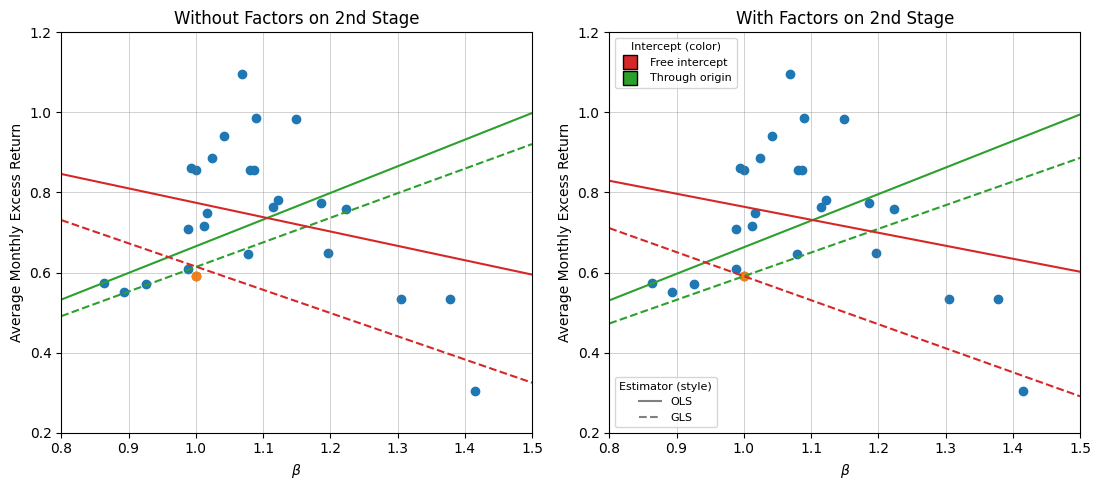

In [7]:
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(5 * (16 / 7.2), 5))

# --- Without test asset ---
ax_nta = plt.subplot2grid((1, 2), (0, 0))
ax_nta.set_title('Without Factors on 2nd Stage')
ax_nta.scatter(cs_reg.betas.values, cs_reg.ret_mean.values, color="tab:blue")
ax_nta.scatter(1, facts["Mkt-RF"].mean(), color='tab:orange')

# OLS no const
c = df2nd.loc[(False, 'OLS', False), 'const']
cp1 = c + df2nd.loc[(False, 'OLS', False), 'lambda']
ax_nta.axline([0, c], [1, cp1], color="tab:green")

# GLS no const
c = df2nd.loc[(False, 'GLS', False), 'const']
cp1 = c + df2nd.loc[(False, 'GLS', False), 'lambda']
ax_nta.axline([0, c], [1, cp1], color="tab:green", ls='--')

# OLS const
c = df2nd.loc[(True, 'OLS', False), 'const']
cp1 = c + df2nd.loc[(True, 'OLS', False), 'lambda']
ax_nta.axline([0, c], [1, cp1], color="tab:red")

# GLS const
c = df2nd.loc[(True, 'GLS', False), 'const']
cp1 = c + df2nd.loc[(True, 'GLS', False), 'lambda']
ax_nta.axline([0, c], [1, cp1], color="tab:red", ls='--')

ax_nta.yaxis.grid(color="grey", linestyle="-", linewidth=0.5, alpha=0.5)
ax_nta.xaxis.grid(color="grey", linestyle="-", linewidth=0.5, alpha=0.5)
ax_nta.set_xlim((0.8, 1.5))
ax_nta.set_ylim((0.2, 1.2))
ax_nta.set_xlabel(r"$\beta$")
ax_nta.set_ylabel("Average Monthly Excess Return")


# --- With test asset ---
ax_ta = plt.subplot2grid((1, 2), (0, 1))
ax_ta.scatter(cs_reg.betas.values, cs_reg.ret_mean.values, color="tab:blue")
ax_ta.scatter(1, facts["Mkt-RF"].mean(), color='tab:orange')
ax_ta.set_title('With Factors on 2nd Stage')

# OLS no const
c = df2nd.loc[(False, 'OLS', True), 'const']
cp1 = c + df2nd.loc[(False, 'OLS', True), 'lambda']
ax_ta.axline([0, c], [1, cp1], color="tab:green")

# GLS no const
c = df2nd.loc[(False, 'GLS', True), 'const']
cp1 = c + df2nd.loc[(False, 'GLS', True), 'lambda']
ax_ta.axline([0, c], [1, cp1], color="tab:green", ls='--')

# OLS const
c = df2nd.loc[(True, 'OLS', True), 'const']
cp1 = c + df2nd.loc[(True, 'OLS', True), 'lambda']
ax_ta.axline([0, c], [1, cp1], color="tab:red")

# GLS const
c = df2nd.loc[(True, 'GLS', True), 'const']
cp1 = c + df2nd.loc[(True, 'GLS', True), 'lambda']
ax_ta.axline([0, c], [1, cp1], color="tab:red", ls='--')

ax_ta.yaxis.grid(color="grey", linestyle="-", linewidth=0.5, alpha=0.5)
ax_ta.xaxis.grid(color="grey", linestyle="-", linewidth=0.5, alpha=0.5)
ax_ta.set_xlim((0.8, 1.5))
ax_ta.set_ylim((0.2, 1.2))
ax_ta.set_xlabel(r"$\beta$")
ax_ta.set_ylabel("Average Monthly Excess Return")

# --- Factored legend: color encodes the intercept, style encodes the estimator ---
color_handles = [
    Line2D([0], [0], marker="s", color="none", markerfacecolor="tab:red", markersize=10, ls=""),
    Line2D([0], [0], marker="s", color="none", markerfacecolor="tab:green", markersize=10, ls=""),
]
style_handles = [
    Line2D([0], [0], color="grey", lw=1.5, ls="-"),
    Line2D([0], [0], color="grey", lw=1.5, ls="--"),
]

leg_color = ax_ta.legend(
    color_handles,
    ["Free intercept", "Through origin"],
    title="Intercept (color)",
    loc="upper left",
    fontsize=8,
    title_fontsize=8,
)
ax_ta.add_artist(leg_color)
ax_ta.legend(
    style_handles,
    ["OLS", "GLS"],
    title="Estimator (style)",
    loc="lower left",
    fontsize=8,
    title_fontsize=8,
)

plt.tight_layout()
plt.show()

In the figure above, the chart on the left does not include the market portfolio as a test factor in the 2nd stage of the regression. The orange dot shows it in the chart, but it is not considered n the regression. The chart on the right actually include the market portfolio in the 2nd stage. The solid lines are the OLS regressions and the dashed lines are the results from the GLS estimator. The red lines have a free intercept and the green lines are forced to pass through the origin.

The first big impact of the design choices is the addition of an intercept or not. For this case of the single market factor, adding a constant to the model not only changes the slope drastically, it even takes it to a negative estimate. A negative market risk premium goes against the theory.


The second big impact comes from the choice of estimator and inclusion of the factor as a test asset. In the OLS case, it is easy to see, both in the chart and in the numbers, that the effect of this addition is very small, as it is just 1 more observation among the other 25 other portfolios. But adding the market portfolio to the 2nd stage and using GLS forces the regression to pass exactly through it, it forces the theory to be true, for the market portfolio to price itself perfectly.